# Algoritmo genético completo — Asistente de Compras Inteligente para Bodegas
### Software Inteligente — Avance de simulación (lógica difusa real + crossover + 1500 generaciones)

Este notebook resuelve los 3 puntos pedidos:

1. **Lógica difusa aplicada** (demanda y riesgo de merma) con funciones de membresía reales, no reglas de umbral duro.
2. **Cadenas concretas para crossover** (2 padres definidos) + operador de crossover de un punto.
3. **Tabla y función matemática de fitness**, ya validada contra el informe del 10%, corriendo en una simulación de 1500 generaciones.

> Nota de diseño: se mantiene la columna de perecibilidad del catálogo (alto/medio/bajo) y se convierte a
> "días de vida útil restante" con un mapeo fijo (alto→3 días, medio→7 días, bajo→20 días) para poder
> usar funciones de membresía reales sin tener que rehacer el catálogo.

In [1]:
import random
import matplotlib.pyplot as plt

random.seed(42)


## 1. Catálogo de 15 productos

In [2]:
productos = [
    {"nombre": "Arroz",                 "categoria": "abarrotes", "precio_compra": 3.50, "precio_venta": 4.50, "perecibilidad": "bajo",  "ventas_4sem": 30},
    {"nombre": "Leche Gloria 1L",       "categoria": "lacteos",   "precio_compra": 4.20, "precio_venta": 5.00, "perecibilidad": "alto",  "ventas_4sem": 25},
    {"nombre": "Aceite",                 "categoria": "abarrotes", "precio_compra": 8.00, "precio_venta": 9.50, "perecibilidad": "bajo",  "ventas_4sem": 12},
    {"nombre": "Fideos",                 "categoria": "abarrotes", "precio_compra": 2.80, "precio_venta": 3.50, "perecibilidad": "bajo",  "ventas_4sem": 22},
    {"nombre": "Atún",                   "categoria": "abarrotes", "precio_compra": 4.50, "precio_venta": 5.50, "perecibilidad": "bajo",  "ventas_4sem": 18},
    {"nombre": "Pan de molde",          "categoria": "panaderia", "precio_compra": 3.80, "precio_venta": 4.80, "perecibilidad": "alto",  "ventas_4sem": 15},
    {"nombre": "Yogurt Gloria",         "categoria": "lacteos",   "precio_compra": 5.20, "precio_venta": 6.50, "perecibilidad": "medio", "ventas_4sem": 14},
    {"nombre": "Gaseosa Coca-Cola 1.5L","categoria": "bebidas",   "precio_compra": 4.80, "precio_venta": 5.50, "perecibilidad": "bajo",  "ventas_4sem": 28},
    {"nombre": "Detergente",            "categoria": "limpieza",  "precio_compra": 6.50, "precio_venta": 8.00, "perecibilidad": "bajo",  "ventas_4sem": 8},
    {"nombre": "Galletas Oreo",         "categoria": "snacks",    "precio_compra": 3.00, "precio_venta": 3.50, "perecibilidad": "medio", "ventas_4sem": 20},
    {"nombre": "Huevos (docena)",       "categoria": "abarrotes", "precio_compra": 6.00, "precio_venta": 7.00, "perecibilidad": "medio", "ventas_4sem": 16},
    {"nombre": "Queso fresco",          "categoria": "lacteos",   "precio_compra": 9.00, "precio_venta": 11.00,"perecibilidad": "alto",  "ventas_4sem": 10},
    {"nombre": "Azúcar",                 "categoria": "abarrotes", "precio_compra": 3.20, "precio_venta": 4.00, "perecibilidad": "bajo",  "ventas_4sem": 9},
    {"nombre": "Papas Lay's",           "categoria": "snacks",    "precio_compra": 3.20, "precio_venta": 4.00, "perecibilidad": "bajo",  "ventas_4sem": 24},
    {"nombre": "Inca Kola 1.5L",        "categoria": "bebidas",   "precio_compra": 4.00, "precio_venta": 5.20, "perecibilidad": "bajo",  "ventas_4sem": 19},
]

DIAS_VIDA_UTIL = {"alto": 3, "medio": 7, "bajo": 20}  # mapeo fijo perecibilidad -> dias

assert len(productos) == 15
print(f"Catalogo cargado con {len(productos)} productos (15 genes).")


Catalogo cargado con 15 productos (15 genes).


In [3]:
solicitud_usuario = {
    "presupuesto": 1500,
    "categorias_prioritarias": ["lacteos", "abarrotes"],
    "incluir_forzado": ["Arroz"],
    "excluir": [],
}
solicitud_usuario


{'presupuesto': 1500,
 'categorias_prioritarias': ['lacteos', 'abarrotes'],
 'incluir_forzado': ['Arroz'],
 'excluir': []}

## 2. Lógica difusa real (funciones de membresía + defuzzificación)

### Función de membresía trapezoidal genérica

```
mu(x) = 0                    si x <= a  o  x >= d
      = (x - a) / (b - a)    si a < x < b
      = 1                    si b <= x <= c
      = (d - x) / (d - c)    si c < x < d
```

Un triángulo es un trapecio con b = c.

### Variable difusa 1: Demanda (entrada = ventas últimas 4 semanas)

| Conjunto | a | b | c | d | valor representativo |
|---|---|---|---|---|---|
| Baja  | 0  | 0  | 5  | 15 | 0.2 |
| Media | 5  | 15 | 15 | 25 | 0.5 |
| Alta  | 15 | 25 | 999| 999| 0.9 |

### Variable difusa 2: Riesgo de merma (entrada = días de vida útil restante)

| Conjunto | a | b | c | d | valor representativo |
|---|---|---|---|---|---|
| Alto  | 0 | 0  | 3  | 7  | 0.8 |
| Medio | 3 | 7  | 7  | 15 | 0.5 |
| Bajo  | 7 | 15 | 999| 999| 0.2 |

### Defuzzificación (promedio ponderado por membresía, estilo Sugeno)

```
score_demanda = (mu_baja*0.2 + mu_media*0.5 + mu_alta*0.9) / (mu_baja + mu_media + mu_alta)
riesgo_merma  = (mu_alto*0.8 + mu_medio*0.5 + mu_bajo*0.2) / (mu_alto + mu_medio + mu_bajo)
```

In [4]:
def membresia_trapezoidal(x, a, b, c, d):
    """Funcion de membresia trapezoidal generica (triangular si b == c)."""
    if x <= a or x >= d:
        return 0.0
    if b <= x <= c:
        return 1.0
    if a < x < b:
        return (x - a) / (b - a)
    if c < x < d:
        return (d - x) / (d - c)
    return 0.0


# --- Variable difusa 1: demanda (entrada: ventas ultimas 4 semanas) ---
def fuzzificar_demanda(ventas):
    mu_baja  = membresia_trapezoidal(ventas, 0, 0, 5, 15)
    mu_media = membresia_trapezoidal(ventas, 5, 15, 15, 25)
    mu_alta  = membresia_trapezoidal(ventas, 15, 25, 999, 999)
    return mu_baja, mu_media, mu_alta

def score_demanda(ventas):
    mu_baja, mu_media, mu_alta = fuzzificar_demanda(ventas)
    suma_mu = mu_baja + mu_media + mu_alta
    if suma_mu == 0:
        return 0.5  # caso borde, no deberia pasar dentro del rango 0-30+
    return (mu_baja * 0.2 + mu_media * 0.5 + mu_alta * 0.9) / suma_mu


# --- Variable difusa 2: riesgo de merma (entrada: dias de vida util restante) ---
def fuzzificar_riesgo(dias):
    mu_alto  = membresia_trapezoidal(dias, 0, 0, 3, 7)
    mu_medio = membresia_trapezoidal(dias, 3, 7, 7, 15)
    mu_bajo  = membresia_trapezoidal(dias, 7, 15, 999, 999)
    return mu_alto, mu_medio, mu_bajo

def riesgo_merma(perecibilidad):
    dias = DIAS_VIDA_UTIL[perecibilidad]
    mu_alto, mu_medio, mu_bajo = fuzzificar_riesgo(dias)
    suma_mu = mu_alto + mu_medio + mu_bajo
    if suma_mu == 0:
        return 0.5
    return (mu_alto * 0.8 + mu_medio * 0.5 + mu_bajo * 0.2) / suma_mu


def peso_categoria(categoria, categorias_prioritarias):
    return 1.3 if categoria in categorias_prioritarias else 1.0


### Verificación rápida (el ejemplo del punto anterior: 18 unidades vendidas)

Con reglas de umbral duro esto daba 0.5 en seco. Con difusa real debería dar ≈0.62 (más cerca de "alta").

In [5]:
prueba = score_demanda(18)
print(f"score_demanda(18 unidades) = {prueba:.2f}  (esperado ~0.62)")
assert abs(prueba - 0.62) < 0.02, "revisar funciones de membresia"
print("OK: la difusa real da un valor intermedio, no un salto de umbral duro.")


score_demanda(18 unidades) = 0.62  (esperado ~0.62)
OK: la difusa real da un valor intermedio, no un salto de umbral duro.


### Tabla difusa aplicada a los 15 productos del catálogo

## 3. Función de fitness

```
Fitness = Sum(cantidad_i * precio_venta_i * score_demanda_i * peso_categoria_i)
        - Penalizacion_presupuesto
        - Penalizacion_restricciones_duras
```

El riesgo de merma ya no forma parte del fitness; ahora limita el rango de cada gen del cromosoma (ver sección 5).

In [6]:
FACTOR_CASTIGO = 10
PENALIZACION_RESTRICCION_DURA = 500
CANTIDAD_MIN, CANTIDAD_MAX = 0, 30


def calcular_fitness(individuo, solicitud):
    parte_positiva = 0.0
    costo_total = 0.0

    for i, prod in enumerate(productos):
        cantidad = individuo[i]
        sd = score_demanda(prod["ventas_4sem"])
        pc = peso_categoria(prod["categoria"], solicitud["categorias_prioritarias"])

        costo_total += cantidad * prod["precio_compra"]
        parte_positiva += cantidad * prod["precio_venta"] * sd * pc

    presupuesto = solicitud["presupuesto"]
    penalizacion_presupuesto = max(0.0, (costo_total - presupuesto) * FACTOR_CASTIGO)

    penalizacion_restricciones = 0.0
    cantidades = {productos[i]["nombre"]: individuo[i] for i in range(len(productos))}
    for nombre in solicitud["incluir_forzado"]:
        if cantidades.get(nombre, 0) == 0:
            penalizacion_restricciones += PENALIZACION_RESTRICCION_DURA
    for nombre in solicitud["excluir"]:
        if cantidades.get(nombre, 0) > 0:
            penalizacion_restricciones += PENALIZACION_RESTRICCION_DURA

    # El riesgo de merma ya no penaliza el fitness; ahora limita directamente el rango de valores que puede tomar cada gen (ver CANTIDAD_MAX_POR_PRODUCTO).
    return parte_positiva - penalizacion_presupuesto - penalizacion_restricciones

### Validación contra el informe (difusa ahora es real, el número puede variar levemente vs. la versión de umbral duro)

In [7]:
individuo_informe = [20, 15, 5, 30, 10, 0, 0, 8, 2, 12, 6, 0, 18, 4, 9]
fitness_informe = calcular_fitness(individuo_informe, solicitud_usuario)
print(f"Fitness del individuo del informe (con difusa real): {fitness_informe:.2f}")
print("(En el informe, con reglas de umbral duro, este mismo individuo dio 364.39;")
print(" la diferencia es esperable porque ahora varias ventas caen en zonas de transicion difusa.)")


Fitness del individuo del informe (con difusa real): 546.89
(En el informe, con reglas de umbral duro, este mismo individuo dio 364.39;
 la diferencia es esperable porque ahora varias ventas caen en zonas de transicion difusa.)


In [8]:
print(f"{'Producto':<24}{'Cant.':>7}{'Demanda':>10}{'Peso cat.':>10}{'Parte (+)':>12}")
print("-" * 68)

parte_positiva_tabla = 0.0
costo_total_tabla = 0.0

for i, prod in enumerate(productos):
    cantidad = individuo_informe[i]
    sd = score_demanda(prod["ventas_4sem"])
    pc = peso_categoria(prod["categoria"], solicitud_usuario["categorias_prioritarias"])
    parte_positiva = cantidad * prod["precio_venta"] * sd * pc
    costo_total_tabla += cantidad * prod["precio_compra"]
    parte_positiva_tabla += parte_positiva
    print(f"{prod['nombre']:<24}{cantidad:>7}{sd:>10.3f}{pc:>10.1f}{parte_positiva:>12.2f}")

# El riesgo ya limita la cadena y no se resta como parte negativa del fitness.
penalizacion_presupuesto_tabla = max(0.0, (costo_total_tabla - solicitud_usuario["presupuesto"]) * FACTOR_CASTIGO)
print("-" * 68)
print(f"Costo total: S/ {costo_total_tabla:.2f}")
print(f"Parte positiva: S/ {parte_positiva_tabla:.2f}")
print(f"Penalizacion de presupuesto: S/ {penalizacion_presupuesto_tabla:.2f}")
print(f"Fitness del individuo: S/ {parte_positiva_tabla - penalizacion_presupuesto_tabla:.2f}")

Producto                  Cant.   Demanda Peso cat.   Parte (+)
--------------------------------------------------------------------
Arroz                        20     0.900       1.3      105.30
Leche Gloria 1L              15     0.900       1.3       87.75
Aceite                        5     0.410       1.3       25.32
Fideos                       30     0.780       1.3      106.47
Atún                         10     0.620       1.3       44.33
Pan de molde                  0     0.500       1.0        0.00
Yogurt Gloria                 0     0.470       1.3        0.00
Gaseosa Coca-Cola 1.5L        8     0.900       1.0       39.60
Detergente                    2     0.290       1.0        4.64
Galletas Oreo                12     0.700       1.0       29.40
Huevos (docena)               6     0.540       1.3       29.48
Queso fresco                  0     0.350       1.3        0.00
Azúcar                       18     0.320       1.3       29.95
Papas Lay's                   4    

## 4. Cadenas concretas para crossover (los 2 padres)

Se definen dos individuos fijos para poder mostrar el crossover funcionando de forma controlada,
antes de dejar que el algoritmo genético trabaje con población aleatoria.

In [9]:
padre_1 = [20, 15, 5, 30, 10, 0,  0,  8,  2,  12, 6,  0,  18, 4,  9]   # orientado a abarrotes
padre_2 = [5,  25, 15, 5,  3,  10, 20, 15, 8,  5,  12, 15, 3,  20, 15]  # orientado a lacteos/snacks

print("Padre 1:", padre_1, "-> fitness:", round(calcular_fitness(padre_1, solicitud_usuario), 2))
print("Padre 2:", padre_2, "-> fitness:", round(calcular_fitness(padre_2, solicitud_usuario), 2))


Padre 1: [20, 15, 5, 30, 10, 0, 0, 8, 2, 12, 6, 0, 18, 4, 9] -> fitness: 546.89
Padre 2: [5, 25, 15, 5, 3, 10, 20, 15, 8, 5, 12, 15, 3, 20, 15] -> fitness: 747.38


### Operador de crossover: un punto de corte

Se elige una posición al azar entre 1 y 14. El hijo A toma los genes 1..corte del padre 1 y corte+1..15
del padre 2; el hijo B es el cruce complementario.

In [10]:
def crossover_un_punto(p1, p2, punto_corte=None):
    if punto_corte is None:
        punto_corte = random.randint(1, len(p1) - 1)
    hijo_a = p1[:punto_corte] + p2[punto_corte:]
    hijo_b = p2[:punto_corte] + p1[punto_corte:]
    return hijo_a, hijo_b, punto_corte

hijo_a, hijo_b, corte = crossover_un_punto(padre_1, padre_2, punto_corte=8)

print(f"Punto de corte: gen {corte}")
print("Padre 1:", padre_1)
print("Padre 2:", padre_2)
print("Hijo A: ", hijo_a, "-> fitness:", round(calcular_fitness(hijo_a, solicitud_usuario), 2))
print("Hijo B: ", hijo_b, "-> fitness:", round(calcular_fitness(hijo_b, solicitud_usuario), 2))


Punto de corte: gen 8
Padre 1: [20, 15, 5, 30, 10, 0, 0, 8, 2, 12, 6, 0, 18, 4, 9]
Padre 2: [5, 25, 15, 5, 3, 10, 20, 15, 8, 5, 12, 15, 3, 20, 15]
Hijo A:  [20, 15, 5, 30, 10, 0, 0, 8, 8, 5, 12, 15, 3, 20, 15] -> fitness: 698.89
Hijo B:  [5, 25, 15, 5, 3, 10, 20, 15, 2, 12, 6, 0, 18, 4, 9] -> fitness: 595.38


In [11]:
# --- El riesgo de merma ahora limita la cadena (rango de cada gen), no el fitness ---
# Coeficiente estatico por ahora: mas adelante se reemplazara por un valor dinamico
# ajustado segun la tolerancia al riesgo que indique el usuario en lenguaje natural.
COEFICIENTE_RIESGO_CADENA = 0.6

CANTIDAD_MAX_POR_PRODUCTO = []
for prod in productos:
    rm = riesgo_merma(prod["perecibilidad"])
    cantidad_max_i = round(CANTIDAD_MAX * (1 - COEFICIENTE_RIESGO_CADENA * rm))
    CANTIDAD_MAX_POR_PRODUCTO.append(cantidad_max_i)

print("Cantidad maxima permitida por gen (segun riesgo de merma):")
for prod, cmax in zip(productos, CANTIDAD_MAX_POR_PRODUCTO):
    print(f"  {prod['nombre']:<24} -> max {cmax} unidades")

Cantidad maxima permitida por gen (segun riesgo de merma):
  Arroz                    -> max 26 unidades
  Leche Gloria 1L          -> max 16 unidades
  Aceite                   -> max 26 unidades
  Fideos                   -> max 26 unidades
  Atún                     -> max 26 unidades
  Pan de molde             -> max 16 unidades
  Yogurt Gloria            -> max 21 unidades
  Gaseosa Coca-Cola 1.5L   -> max 26 unidades
  Detergente               -> max 26 unidades
  Galletas Oreo            -> max 21 unidades
  Huevos (docena)          -> max 21 unidades
  Queso fresco             -> max 16 unidades
  Azúcar                   -> max 26 unidades
  Papas Lay's              -> max 26 unidades
  Inca Kola 1.5L           -> max 26 unidades


## 5. Algoritmo genético completo — simulación de 1500 generaciones

Parámetros:

| Parámetro | Valor |
|---|---|
| Tamaño de población | 40 |
| Selección | Torneo de 3 |
| Tasa de crossover | 0.8 |
| Tasa de mutación | 0.08 por gen |
| Elitismo | 1 mejor individuo se conserva siempre |
| Generaciones | 1500 |

In [12]:
TAMANO_POBLACION = 40
GENERACIONES = 1500
TASA_CROSSOVER = 0.8
TASA_MUTACION = 0.08
TAMANO_TORNEO = 3
ELITISMO = 1


def generar_individuo():
    # Cada gen usa su propio tope (CANTIDAD_MAX_POR_PRODUCTO), no un CANTIDAD_MAX fijo para todos.
    individuo = [random.randint(CANTIDAD_MIN, CANTIDAD_MAX_POR_PRODUCTO[i]) for i in range(len(productos))]
    for i, prod in enumerate(productos):
        if prod["nombre"] in solicitud_usuario["incluir_forzado"] and individuo[i] == 0:
            individuo[i] = random.randint(1, CANTIDAD_MAX_POR_PRODUCTO[i])
    return individuo


def seleccion_torneo(poblacion_evaluada, k=TAMANO_TORNEO):
    participantes = random.sample(poblacion_evaluada, k)
    ganador = max(participantes, key=lambda x: x[1])
    return ganador[0]


def mutar(individuo):
    nuevo = individuo[:]
    for i in range(len(nuevo)):
        if random.random() < TASA_MUTACION:
            nuevo[i] = random.randint(CANTIDAD_MIN, CANTIDAD_MAX_POR_PRODUCTO[i])
    for i, prod in enumerate(productos):
        if prod["nombre"] in solicitud_usuario["incluir_forzado"] and nuevo[i] == 0:
            nuevo[i] = random.randint(1, CANTIDAD_MAX_POR_PRODUCTO[i])
    return nuevo


poblacion = [generar_individuo() for _ in range(TAMANO_POBLACION)]
# padre_1 y padre_2 se definieron antes de introducir el tope por gen; se recortan aqui
# para que la poblacion inicial respete las nuevas restricciones de la cadena.
poblacion[0] = [min(padre_1[i], CANTIDAD_MAX_POR_PRODUCTO[i]) for i in range(len(padre_1))]
poblacion[1] = [min(padre_2[i], CANTIDAD_MAX_POR_PRODUCTO[i]) for i in range(len(padre_2))]
poblacion_inicial = [individuo[:] for individuo in poblacion]

historial_mejor_fitness = []
mejor_individuo_global = None
mejor_fitness_global = float("-inf")

for gen in range(GENERACIONES):
    evaluada = [(ind, calcular_fitness(ind, solicitud_usuario)) for ind in poblacion]
    evaluada.sort(key=lambda x: x[1], reverse=True)

    if evaluada[0][1] > mejor_fitness_global:
        mejor_fitness_global = evaluada[0][1]
        mejor_individuo_global = evaluada[0][0][:]

    historial_mejor_fitness.append(evaluada[0][1])

    nueva_poblacion = [ind for ind, _ in evaluada[:ELITISMO]]

    while len(nueva_poblacion) < TAMANO_POBLACION:
        padre_a = seleccion_torneo(evaluada)
        padre_b = seleccion_torneo(evaluada)

        if random.random() < TASA_CROSSOVER:
            hijo_a, hijo_b, _ = crossover_un_punto(padre_a, padre_b)
        else:
            hijo_a, hijo_b = padre_a[:], padre_b[:]

        nueva_poblacion.append(mutar(hijo_a))
        if len(nueva_poblacion) < TAMANO_POBLACION:
            nueva_poblacion.append(mutar(hijo_b))

    poblacion = nueva_poblacion

print(f"Simulacion completa: {GENERACIONES} generaciones")
print(f"Mejor fitness encontrado: {mejor_fitness_global:.2f}")
print(f"Mejor individuo: {mejor_individuo_global}")

Simulacion completa: 1500 generaciones
Mejor fitness encontrado: 1293.07
Mejor individuo: [26, 16, 26, 26, 26, 16, 21, 26, 7, 21, 21, 16, 26, 26, 26]


### Tabla de la población inicial

La población inicial contiene 40 individuos. Cada individuo es un cromosoma de 15 genes, y se evalúa mediante su costo total y su función de fitness.

In [13]:
print(f"{'Individuo':>10}  {'Cromosoma':<65} {'Costo (S/)':>12} {'Fitness':>12}")
print("-" * 104)

for numero, individuo in enumerate(poblacion_inicial, start=1):
    costo = sum(individuo[i] * productos[i]["precio_compra"] for i in range(len(productos)))
    fitness = calcular_fitness(individuo, solicitud_usuario)
    print(f"{numero:>10}  {str(individuo):<65} {costo:>12.2f} {fitness:>12.2f}")

print(f"\nTotal de individuos iniciales: {len(poblacion_inicial)}")
print(f"Genes por individuo: {len(poblacion_inicial[0])}")

 Individuo  Cromosoma                                                           Costo (S/)      Fitness
--------------------------------------------------------------------------------------------------------
         1  [20, 15, 5, 26, 10, 0, 0, 8, 2, 12, 6, 0, 18, 4, 9]                     520.60       532.70
         2  [5, 16, 15, 5, 3, 10, 20, 15, 8, 5, 12, 15, 3, 20, 15]                  853.80       694.73
         3  [25, 0, 24, 25, 5, 13, 10, 8, 4, 6, 10, 3, 2, 12, 3]                    699.60       617.59
         4  [11, 11, 19, 8, 25, 1, 14, 17, 3, 12, 2, 9, 26, 20, 19]                 901.50       768.34
         5  [11, 6, 22, 2, 1, 7, 9, 2, 7, 3, 12, 8, 14, 20, 26]                     744.10       582.31
         6  [11, 5, 11, 11, 6, 8, 21, 20, 2, 19, 20, 5, 17, 23, 7]                  831.90       716.03
         7  [5, 14, 12, 8, 20, 7, 21, 10, 26, 1, 7, 1, 25, 10, 12]                  851.50       655.10
         8  [8, 2, 6, 18, 22, 10, 6, 20, 15, 12, 20, 14, 4, 8, 

### Resumen de convergencia

Para la exposición se muestran algunas generaciones representativas. La generación 0 corresponde a la población inicial.

In [14]:
generaciones_mostradas = [0, 1, 10, 100, 500, 1000, 1499]
print(f"{'Generacion':>12}  {'Mejor fitness':>16}")
print("-" * 32)
for generacion in generaciones_mostradas:
    print(f"{generacion:>12}  {historial_mejor_fitness[generacion]:>16.2f}")

  Generacion     Mejor fitness
--------------------------------
           0            830.53
           1            869.54
          10           1165.69
         100           1279.13
         500           1285.93
        1000           1293.07
        1499           1293.07


### Detalle del mejor individuo encontrado

In [15]:
costo_final = sum(mejor_individuo_global[i] * productos[i]["precio_compra"] for i in range(15))
print(f"Costo total: S/ {costo_final:.2f}  (presupuesto: S/ {solicitud_usuario['presupuesto']})")
print(f"Fitness final: {mejor_fitness_global:.2f}")
print()
for i, prod in enumerate(productos):
    if mejor_individuo_global[i] > 0:
        print(f"  {prod['nombre']:<24} -> {mejor_individuo_global[i]:>2} unidades")


Costo total: S/ 1499.70  (presupuesto: S/ 1500)
Fitness final: 1293.07

  Arroz                    -> 26 unidades
  Leche Gloria 1L          -> 16 unidades
  Aceite                   -> 26 unidades
  Fideos                   -> 26 unidades
  Atún                     -> 26 unidades
  Pan de molde             -> 16 unidades
  Yogurt Gloria            -> 21 unidades
  Gaseosa Coca-Cola 1.5L   -> 26 unidades
  Detergente               ->  7 unidades
  Galletas Oreo            -> 21 unidades
  Huevos (docena)          -> 21 unidades
  Queso fresco             -> 16 unidades
  Azúcar                   -> 26 unidades
  Papas Lay's              -> 26 unidades
  Inca Kola 1.5L           -> 26 unidades


### Gráfico de convergencia (fitness del mejor individuo por generación)

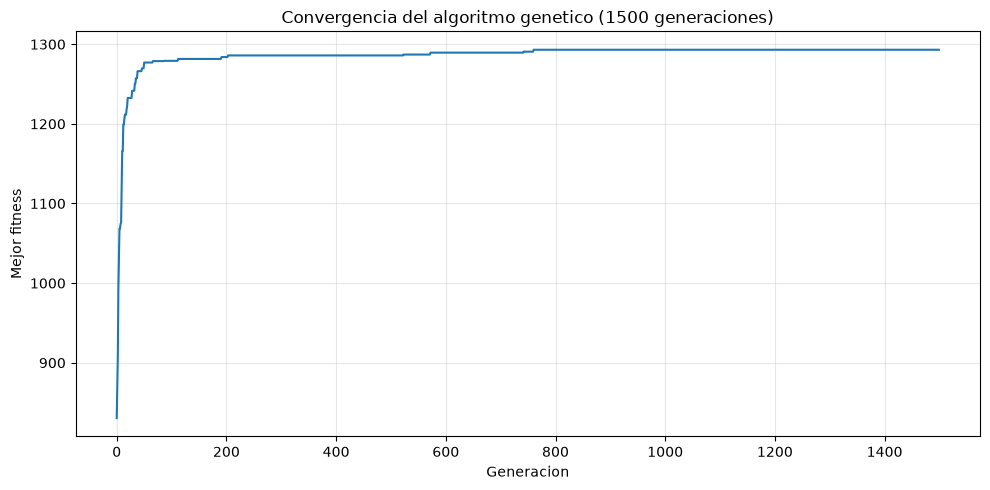

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(historial_mejor_fitness)
plt.title("Convergencia del algoritmo genetico (1500 generaciones)")
plt.xlabel("Generacion")
plt.ylabel("Mejor fitness")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("convergencia.png", dpi=100)
plt.show()


## Conclusión

- La **lógica difusa** usa funciones de membresía trapezoidales/triangulares y defuzzificación por promedio ponderado. `score_demanda` sigue siendo el único término difuso que participa en el fitness.
- El **riesgo de merma** ya no penaliza el fitness: acota el rango máximo permitido de cada gen en la cadena, según la perecibilidad del producto.
- Se definieron **2 cadenas concretas (padres)** y se probó el operador de **crossover de un punto**, mostrando los 2 hijos resultantes con su fitness. Para la población inicial, los padres se recortan a los topes por gen.
- El **algoritmo genético completo** (selección por torneo, crossover, mutación y elitismo) corrió **1500 generaciones** con una población de 40 individuos, respetando el presupuesto y las restricciones duras.